# Session 8 - Probability Distributions (Discrete)

In [1]:
import numpy as np
from scipy.stats import binom, poisson
import matplotlib.pyplot as plt

np.random.seed(42)

## Task 1 — Bernoulli Trial: Zomato Login Success

Each login attempt is a Bernoulli trial: success (1) with probability p = 0.85, failure (0) otherwise.

In [2]:
p_login_success = 0.85
login_attempts = np.random.binomial(1, p_login_success, size=20)

print('Login results (1=success, 0=failure):', login_attempts.tolist())
print('Successes:', login_attempts.sum(), 'out of 20')

Login results (1=success, 0=failure): [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Successes: 17 out of 20


## Task 2 — Binomial: Exactly 3 Successful UPI Payments Out of 5

In [3]:
def prob_exact_successes(n, k, p):
    return binom.pmf(k, n, p)

p_exact_3 = prob_exact_successes(n=5, k=3, p=0.9)
print('P(exactly 3 successful payments out of 5) =', p_exact_3)

P(exactly 3 successful payments out of 5) = 0.07289999999999998


**Interpretation:** Even with a high 90% per-payment success rate, the probability of *exactly* 3 successes out of 5 is only about **7.3%** — most of the probability mass sits at 4 or 5 successes instead, since a 90% success rate means failures are rare.

## Task 3 — Poisson: Exactly 6 Playlist Creations in a Minute

Average rate λ = 4 playlists/minute on Spotify.

In [4]:
lam = 4
p_exact_6 = poisson.pmf(6, lam)

print('P(exactly 6 playlists created in a minute) =', p_exact_6)

P(exactly 6 playlists created in a minute) = 0.10419563456702102


## Task 4 — Poisson: Simulating Flipkart Reviews per Hour

Average rate λ = 10 reviews/hour, simulated across 12 randomly selected hours.

Simulated reviews per hour: [11, 8, 10, 7, 11, 11, 8, 12, 6, 7, 8, 10]
Mean across the 12 hours: 9.083333333333334


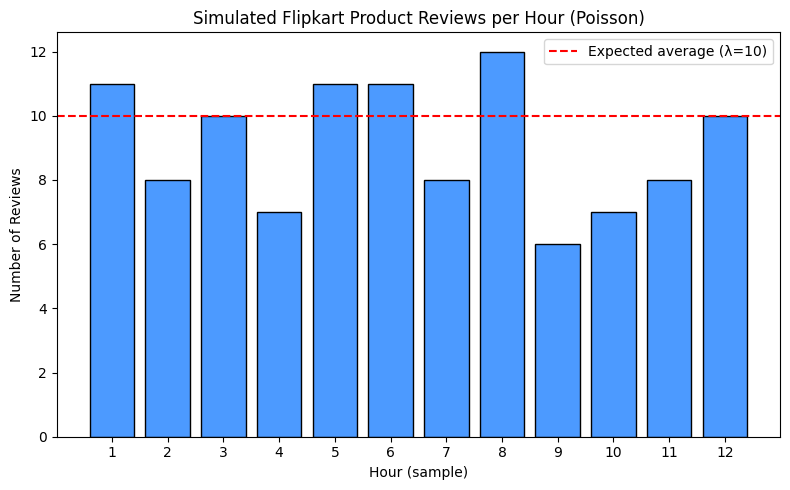

In [5]:
avg_reviews_per_hour = 10
hours = np.arange(1, 13)
simulated_reviews = np.random.poisson(avg_reviews_per_hour, size=12)

print('Simulated reviews per hour:', simulated_reviews.tolist())
print('Mean across the 12 hours:', simulated_reviews.mean())

plt.figure(figsize=(8, 5))
plt.bar(hours, simulated_reviews, color='#4c9aff', edgecolor='black')
plt.axhline(avg_reviews_per_hour, color='red', linestyle='--', label='Expected average (λ=10)')
plt.title('Simulated Flipkart Product Reviews per Hour (Poisson)')
plt.xlabel('Hour (sample)')
plt.ylabel('Number of Reviews')
plt.xticks(hours)
plt.legend()
plt.tight_layout()
plt.show()

## Task 5 — AI-Generated Real-World Use-Case: Poisson Distribution (BookMyShow)

**AI-generated use-case:** BookMyShow can model the number of ticket bookings arriving per minute during the opening hour of a highly anticipated movie release using a Poisson distribution. Since bookings from different users happen independently and the average booking rate stays roughly steady during that opening window, the count of bookings in any given minute follows a Poisson process. This lets BookMyShow forecast server load, anticipate when a show is likely to sell out, and decide when to open additional showtimes — all from a single rate parameter (average bookings per minute) rather than tracking every individual booking pattern.

**Why Poisson fits:** the events (bookings) are discrete, independent, and occur at a roughly constant average rate over a fixed time window — exactly the conditions a Poisson distribution is built for, unlike Binomial (which needs a fixed number of trials) or Bernoulli (a single yes/no outcome).